In [1]:
import pandas as pd
import joblib
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Load saved model and vectorizer
model = joblib.load('../models/fake_review_model.pkl')
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

# Load preprocessed data
df = pd.read_csv("../data/reviews_preprocessed.csv")
df = df.dropna(subset=['clean_text'])
df['clean_text'] = df['clean_text'].astype(str)

print("✅ Model loaded!")
print("✅ Vectorizer loaded!")
print("✅ Data loaded:", df.shape)

✅ Model loaded!
✅ Vectorizer loaded!
✅ Data loaded: (22496, 4)


In [2]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# SHAP works on small samples — take 100 test reviews
X_sample = X_test_tfidf[:100]

print("✅ Sample ready:", X_sample.shape)

✅ Sample ready: (100, 10000)


In [3]:
import shap

print("Calculating SHAP values... (takes 1-2 mins)")

# LinearExplainer works with Logistic Regression
explainer = shap.LinearExplainer(
    model, 
    X_train_tfidf,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values calculated!")
print("Shape of SHAP values:", shap_values.shape)

c:\Users\Sarthak\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculating SHAP values... (takes 1-2 mins)
✅ SHAP values calculated!
Shape of SHAP values: (100, 10000)


c:\Users\Sarthak\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


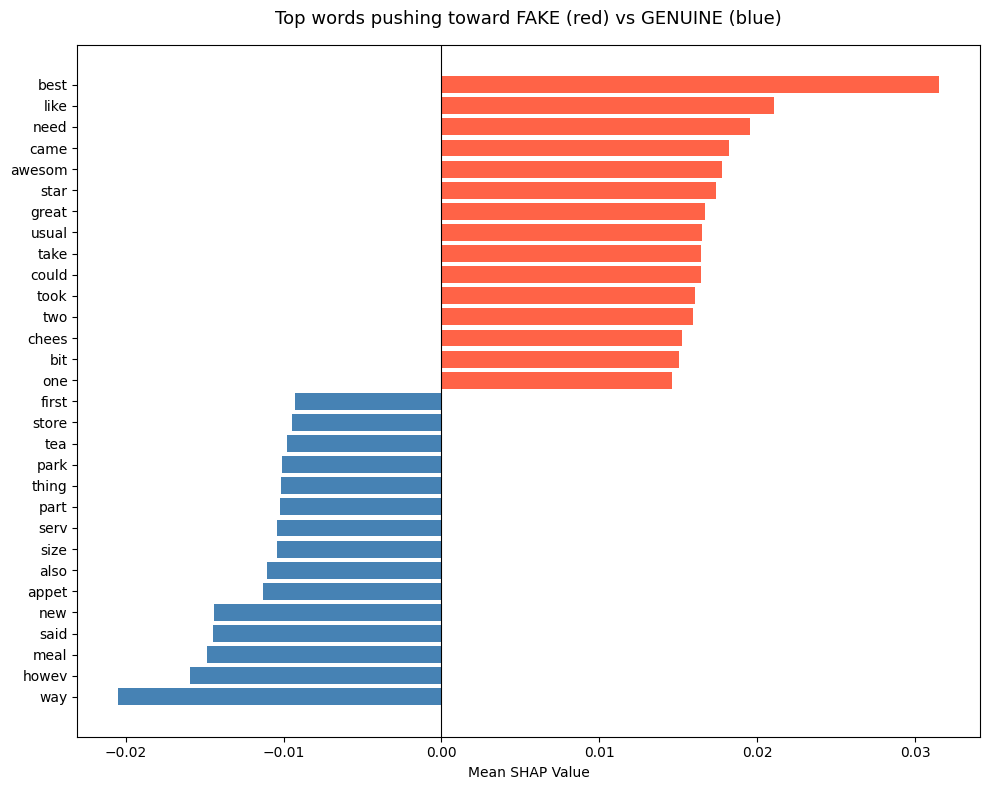

✅ Chart saved!


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Average SHAP values across all 100 samples
mean_shap = shap_values.mean(axis=0)

# Get top 15 words with highest positive SHAP (→ FAKE)
# and top 15 words with highest negative SHAP (→ GENUINE)
top_fake_idx    = np.argsort(mean_shap)[-15:]
top_genuine_idx = np.argsort(mean_shap)[:15]

combined_idx    = np.concatenate([top_genuine_idx, top_fake_idx])
combined_values = mean_shap[combined_idx]
combined_words  = feature_names[combined_idx]

colors = ['steelblue' if v < 0 else 'tomato' for v in combined_values]

plt.figure(figsize=(10, 8))
plt.barh(combined_words, combined_values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top words pushing toward FAKE (red) vs GENUINE (blue)', 
          fontsize=13, pad=15)
plt.xlabel('Mean SHAP Value')
plt.tight_layout()
plt.savefig('../data/shap_top_words.png', dpi=150)
plt.show()
print("✅ Chart saved!")

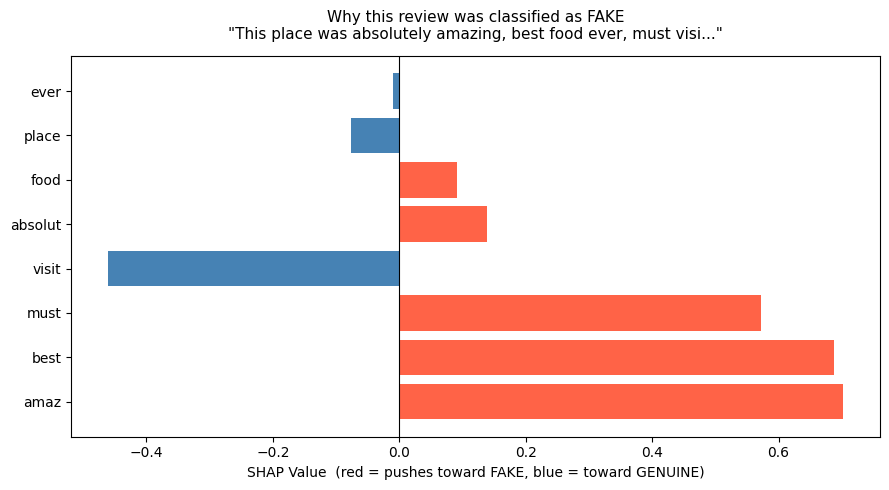

✅ Single review explanation saved!


In [5]:
# Pick one review and explain exactly why it was classified
sample_review = "This place was absolutely amazing, best food ever, must visit!"

# Clean it
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
text_clean = sample_review.lower()
text_clean = re.sub(r'[^a-z\s]', '', text_clean)
words = text_clean.split()
words = [stemmer.stem(w) for w in words if w not in stop_words]
clean = ' '.join(words)

# Vectorize
vec = vectorizer.transform([clean])

# SHAP for this single review
single_shap = explainer.shap_values(vec)[0]

# Get words present in this review with their SHAP scores
word_shap = []
for word in clean.split():
    if word in vectorizer.vocabulary_:
        idx = vectorizer.vocabulary_[word]
        word_shap.append((word, single_shap[idx]))

# Sort by absolute impact
word_shap = sorted(word_shap, key=lambda x: abs(x[1]), reverse=True)[:10]

words_list  = [w[0] for w in word_shap]
values_list = [w[1] for w in word_shap]
colors      = ['tomato' if v > 0 else 'steelblue' for v in values_list]

plt.figure(figsize=(9, 5))
plt.barh(words_list, values_list, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title(f'Why this review was classified as FAKE\n"{sample_review[:60]}..."',
          fontsize=11, pad=12)
plt.xlabel('SHAP Value  (red = pushes toward FAKE, blue = toward GENUINE)')
plt.tight_layout()
plt.savefig('../data/shap_single_review.png', dpi=150)
plt.show()
print("✅ Single review explanation saved!")

In [6]:
joblib.dump(explainer, '../models/shap_explainer.pkl')
print("✅ SHAP explainer saved!")
print("\n📁 Your models/ folder now has:")
print("   - fake_review_model.pkl")
print("   - tfidf_vectorizer.pkl") 
print("   - shap_explainer.pkl")

✅ SHAP explainer saved!

📁 Your models/ folder now has:
   - fake_review_model.pkl
   - tfidf_vectorizer.pkl
   - shap_explainer.pkl
